# Heart Disease — Data Preprocessing

This notebook prepares the Cleveland Heart Disease dataset for machine
learning.

The preprocessing workflow includes:

1. Loading the inspected dataset
2. Handling missing-value markers
3. Creating the binary prediction target
4. Separating features and target
5. Performing a stratified train-test split
6. Building a leakage-safe preprocessing pipeline
7. Handling missing numerical and categorical values
8. Encoding categorical features
9. Scaling numerical features
10. Validating the transformed datasets

All preprocessing transformations are fitted using the training data only.

## 1. Imports

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## 2. Load Dataset

The processed Cleveland dataset contains 303 observations, 13 input
features, and the original `num` target.

The dataset is loaded without applying any transformations at this stage.

In [5]:
heart_columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]

heart_df = pd.read_csv(
    "../../data/raw/cleveland.data",
    header=None,
    names=heart_columns
)

print("Shape:", heart_df.shape)

display(heart_df.head())

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Missing-Value Representation

The Cleveland dataset represents missing values using `?`.

From the inspection stage:

- `ca` contains 4 missing values.
- `thal` contains 2 missing values.

These markers are converted to `NaN` so that they can be handled by the
machine-learning preprocessing pipeline.

No imputation is performed manually at this stage.

In [6]:
heart_df = heart_df.replace("?", np.nan)

print("Missing values after conversion:")
print(heart_df.isnull().sum())

Missing values after conversion:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


## 4. Target Transformation

The original Cleveland target `num` contains five values:

- `0` → no heart disease
- `1`, `2`, `3`, `4` → heart disease present

For this project, the prediction task is binary classification.

Therefore:

- `num = 0` → target `0`
- `num > 0` → target `1`

The original `num` column is retained until the target transformation is
verified and is then removed from the feature matrix.

In [7]:
heart_df["target"] = (
    heart_df["num"].astype(int) > 0
).astype(int)

print("Binary target distribution:")
print(heart_df["target"].value_counts().sort_index())

print("\nBinary target percentages:")
print(
    (
        heart_df["target"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64

Binary target percentages:
target
0    54.13
1    45.87
Name: proportion, dtype: float64


## 5. Feature-Target Separation

The original `num` target is removed from the feature matrix.

The newly created binary `target` is separated as `y`.

No preprocessing transformation is applied before the train-test split.

In [8]:
X = heart_df.drop(
    columns=["num", "target"]
)

y = heart_df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

X shape: (303, 13)
y shape: (303,)

X columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 6. Stratified Train-Test Split

The dataset is divided into training and test sets before fitting any
preprocessing transformations.

A stratified split is used so that the proportion of the two target
classes is approximately preserved in both sets.

The test set remains untouched until model evaluation.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

Training set:
X_train: (242, 13)
y_train: (242,)

Test set:
X_test: (61, 13)
y_test: (61,)

Training target distribution:
target
0    0.5413
1    0.4587
Name: proportion, dtype: float64

Test target distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


## 7. Define Feature Groups

The Cleveland dataset contains numerical and categorical/discrete
features.

Categorical features will be handled using imputation followed by
one-hot encoding.

Numerical features will be handled using median imputation followed
by standardization.

The preprocessing transformations will be fitted only on the training
data through a `ColumnTransformer` pipeline.

In [10]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal features:", len(numerical_features) + len(categorical_features))

Numerical features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Total features: 13


## 8. Numerical Preprocessing

Numerical preprocessing consists of:

1. Median imputation for missing values.
2. Standardization using `StandardScaler`.

Median imputation is selected because it is less sensitive to extreme
values than mean imputation.

The imputer and scaler will be fitted only on the training data.

In [11]:
numerical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

## 9. Categorical Preprocessing

Categorical preprocessing consists of:

1. Replacing missing categorical values using the most frequent value.
2. One-hot encoding categorical variables.

Unknown categories that may appear in future prediction data are ignored
by the encoder rather than causing an error.

In [12]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

## 10. Combined Preprocessing Pipeline

A `ColumnTransformer` combines the numerical and categorical
preprocessing pipelines.

The resulting transformer provides one reproducible preprocessing
workflow that can later be integrated directly with machine-learning
models.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])


## 11. Fit Preprocessing on Training Data

The preprocessing transformer is fitted exclusively on `X_train`.

The test set is only transformed using parameters learned from the
training set.

This prevents information from the test set from influencing:

- Missing-value imputation
- Feature scaling
- Categorical encoding

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (242, 28)
Processed test shape: (61, 28)


## 12. Preprocessing Validation

The transformed training and test datasets are checked for:

- Remaining missing values
- Infinite values
- Numerical scaling
- Consistent feature dimensions
- Generated feature names

The test data is only transformed using preprocessing parameters learned
from the training data.

In [15]:
# Check for missing values
print("Missing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed test data:",
      np.isnan(X_test_processed).sum())

# Check for infinite values
print("\nInfinite values in training data:",
      np.isinf(X_train_processed).sum())

print("Infinite values in test data:",
      np.isinf(X_test_processed).sum())

# Verify shapes
print("\nTraining shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

Missing values in processed training data: 0
Missing values in processed test data: 0

Infinite values in training data: 0
Infinite values in test data: 0

Training shape: (242, 28)
Test shape: (61, 28)


In [16]:
# The first 5 columns correspond to numerical features
X_train_numeric = X_train_processed[:, :len(numerical_features)]

print("Training numerical feature means:")
print(np.round(X_train_numeric.mean(axis=0), 4))

print("\nTraining numerical feature standard deviations:")
print(np.round(X_train_numeric.std(axis=0), 4))

Training numerical feature means:
[-0. -0.  0.  0. -0.]

Training numerical feature standard deviations:
[1. 1. 1. 1. 1.]


In [17]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

print("\nTransformed feature names:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i:2d}. {feature}")

Number of transformed features: 28

Transformed feature names:
 1. num__age
 2. num__trestbps
 3. num__chol
 4. num__thalach
 5. num__oldpeak
 6. cat__sex_0.0
 7. cat__sex_1.0
 8. cat__cp_1.0
 9. cat__cp_2.0
10. cat__cp_3.0
11. cat__cp_4.0
12. cat__fbs_0.0
13. cat__fbs_1.0
14. cat__restecg_0.0
15. cat__restecg_1.0
16. cat__restecg_2.0
17. cat__exang_0.0
18. cat__exang_1.0
19. cat__slope_1.0
20. cat__slope_2.0
21. cat__slope_3.0
22. cat__ca_0.0
23. cat__ca_1.0
24. cat__ca_2.0
25. cat__ca_3.0
26. cat__thal_3.0
27. cat__thal_6.0
28. cat__thal_7.0


In [18]:
print("NUMERICAL IMPUTATION VALUES")
print("-" * 40)

num_imputer = (
    preprocessor
    .named_transformers_["num"]
    .named_steps["imputer"]
)

for feature, value in zip(
    numerical_features,
    num_imputer.statistics_
):
    print(f"{feature:10s}: {value:.4f}")


print("\nCATEGORICAL IMPUTATION VALUES")
print("-" * 40)

cat_imputer = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["imputer"]
)

for feature, value in zip(
    categorical_features,
    cat_imputer.statistics_
):
    print(f"{feature:10s}: {value}")

NUMERICAL IMPUTATION VALUES
----------------------------------------
age       : 56.0000
trestbps  : 130.0000
chol      : 244.5000
thalach   : 153.5000
oldpeak   : 0.8000

CATEGORICAL IMPUTATION VALUES
----------------------------------------
sex       : 1.0
cp        : 4.0
fbs       : 0.0
restecg   : 0.0
exang     : 0.0
slope     : 1.0
ca        : 0.0
thal      : 3.0


In [19]:
print("CATEGORICAL CATEGORIES LEARNED")
print("-" * 40)

encoder = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
)

for feature, categories in zip(
    categorical_features,
    encoder.categories_
):
    print(f"{feature:10s}: {categories}")

CATEGORICAL CATEGORIES LEARNED
----------------------------------------
sex       : [0.0 1.0]
cp        : [1.0 2.0 3.0 4.0]
fbs       : [0.0 1.0]
restecg   : [0.0 1.0 2.0]
exang     : [0.0 1.0]
slope     : [1.0 2.0 3.0]
ca        : ['0.0' '1.0' '2.0' '3.0']
thal      : ['3.0' '6.0' '7.0']


In [28]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

In [21]:
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Baseline models created:")
for name in baseline_models:
    print("-", name)

Baseline models created:
- Logistic Regression
- Random Forest
- Gradient Boosting


In [22]:
baseline_pipelines = {}

for name, model in baseline_models.items():
    baseline_pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("Baseline pipelines created:")
for name in baseline_pipelines:
    print("-", name)

Baseline pipelines created:
- Logistic Regression
- Random Forest
- Gradient Boosting


In [23]:
for name, pipeline in baseline_pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name}: training completed")

Logistic Regression: training completed
Random Forest: training completed
Gradient Boosting: training completed


In [24]:
baseline_results = []

for name, pipeline in baseline_pipelines.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
1,Random Forest,0.8689,0.8125,0.9286,0.8667,0.9426
2,Gradient Boosting,0.8689,0.8125,0.9286,0.8667,0.9470


In [25]:
for name, pipeline in baseline_pipelines.items():

    y_pred = pipeline.predict(X_test)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Heart Disease", "Heart Disease"],
            zero_division=0
        )
    )


Logistic Regression
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.85      0.89        33
   Heart Disease       0.84      0.93      0.88        28

        accuracy                           0.89        61
       macro avg       0.89      0.89      0.89        61
    weighted avg       0.89      0.89      0.89        61


Random Forest
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.82      0.87        33
   Heart Disease       0.81      0.93      0.87        28

        accuracy                           0.87        61
       macro avg       0.87      0.87      0.87        61
    weighted avg       0.88      0.87      0.87        61


Gradient Boosting
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.82      0.87        33
   Heart Disease       0.81      0.93      0.87        28

        accuracy                           0.87        61
       ma

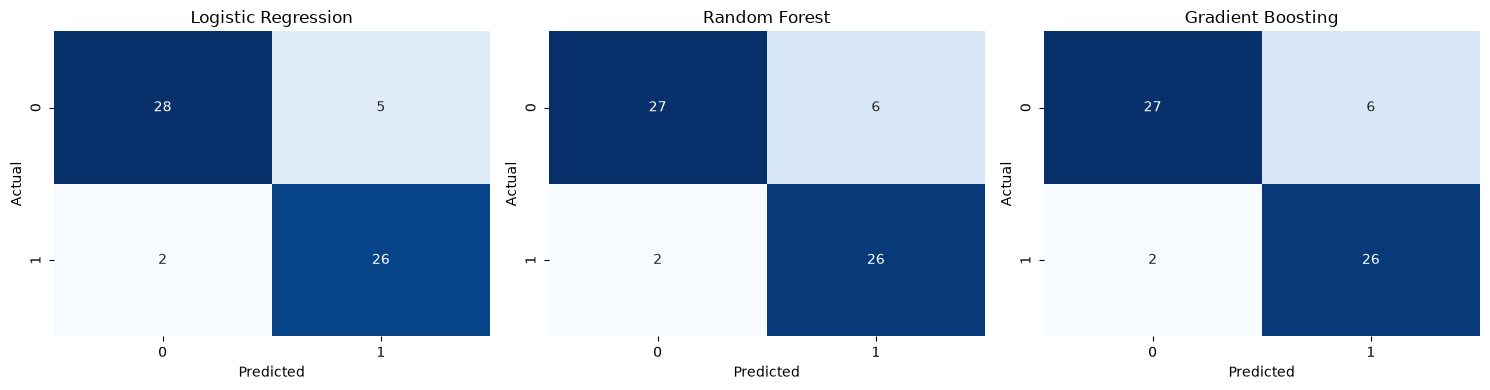

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipeline) in zip(axes, baseline_pipelines.items()):

    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

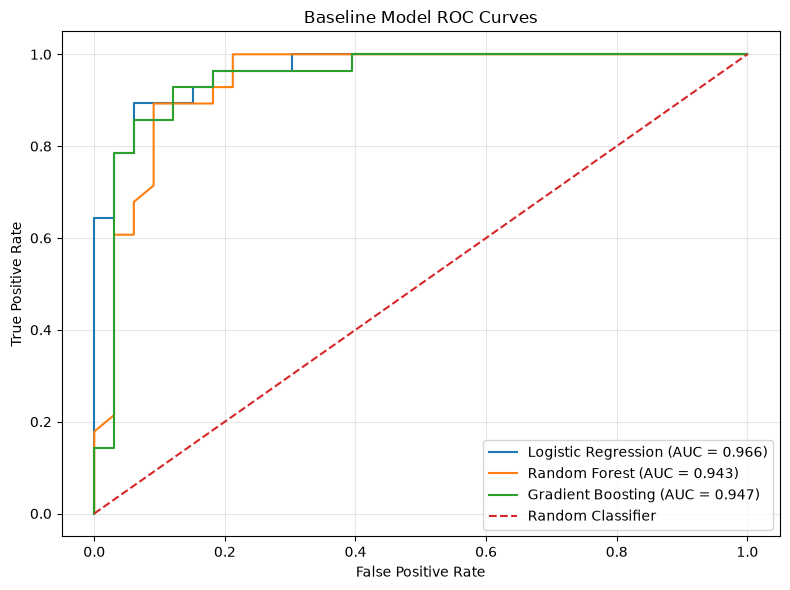

In [29]:
plt.figure(figsize=(8, 6))

for name, pipeline in baseline_pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline Model ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
baseline_results_df = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            pipeline.predict(X_test)
        ),
        "Precision": precision_score(
            y_test,
            pipeline.predict(X_test),
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pipeline.predict(X_test),
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            pipeline.predict(X_test),
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            pipeline.predict_proba(X_test)[:, 1]
        )
    }
    for name, pipeline in baseline_pipelines.items()
])

baseline_results_df = baseline_results_df.round(4)

print("BASELINE MODEL COMPARISON")
print("=" * 70)
display(baseline_results_df)

BASELINE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
1,Random Forest,0.8689,0.8125,0.9286,0.8667,0.9426
2,Gradient Boosting,0.8689,0.8125,0.9286,0.8667,0.9470


In [31]:
from sklearn.model_selection import GridSearchCV

logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

logistic_grid = GridSearchCV(
    estimator=baseline_pipelines["Logistic Regression"],
    param_grid=logistic_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Best parameters:")
print(logistic_grid.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(logistic_grid.best_score_, 4))

print("\nBest Logistic Regression pipeline created successfully.")

Best parameters:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best cross-validation ROC-AUC:
0.8989

Best Logistic Regression pipeline created successfully.


c:\Users\mvans\OneDrive\Desktop\Healytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [32]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 3, 5, 7],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=baseline_pipelines["Random Forest"],
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(rf_grid.best_score_, 4))

print("\nBest Random Forest pipeline created successfully.")

Best parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best cross-validation ROC-AUC:
0.906

Best Random Forest pipeline created successfully.


In [33]:
gb_param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_split": [2, 5, 10]
}

gb_grid = GridSearchCV(
    estimator=baseline_pipelines["Gradient Boosting"],
    param_grid=gb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best parameters:")
print(gb_grid.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(gb_grid.best_score_, 4))

print("\nBest Gradient Boosting pipeline created successfully.")

Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_split': 2, 'model__n_estimators': 50}

Best cross-validation ROC-AUC:
0.8811

Best Gradient Boosting pipeline created successfully.


In [35]:
tuned_pipelines = {
    "Tuned Logistic Regression": logistic_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}

tuned_results = []

for name, pipeline in tuned_pipelines.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results).round(4)

print("TUNED MODEL COMPARISON")
print("=" * 70)

display(tuned_results_df)

TUNED MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
1,Tuned Random Forest,0.8689,0.8333,0.8929,0.8621,0.9502
2,Tuned Gradient Boosting,0.8852,0.8621,0.8929,0.8772,0.9535


In [36]:
baseline_comparison = baseline_results_df.copy()
baseline_comparison["Version"] = "Baseline"

tuned_comparison = tuned_results_df.copy()
tuned_comparison["Version"] = "Tuned"

model_comparison = pd.concat(
    [baseline_comparison, tuned_comparison],
    ignore_index=True
)

model_comparison = model_comparison[
    ["Version", "Model", "Accuracy", "Precision",
     "Recall", "F1-Score", "ROC-AUC"]
]

display(model_comparison.round(4))

,Version,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
1,Baseline,Random Forest,0.8689,0.8125,0.9286,0.8667,0.9426
2,Baseline,Gradient Boosting,0.8689,0.8125,0.9286,0.8667,0.9470
3,Tuned,Tuned Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
4,Tuned,Tuned Random Forest,0.8689,0.8333,0.8929,0.8621,0.9502
5,Tuned,Tuned Gradient Boosting,0.8852,0.8621,0.8929,0.8772,0.9535


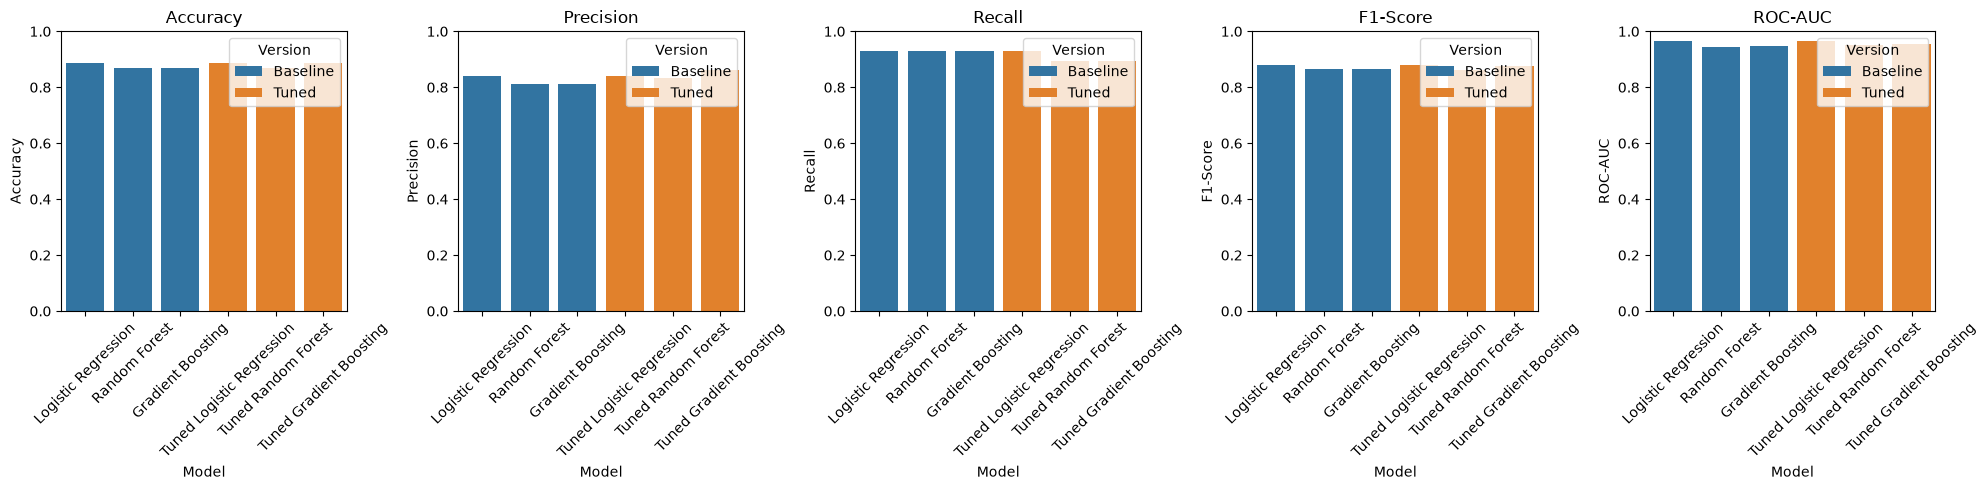

In [37]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, metric in zip(axes, metrics):

    plot_df = model_comparison.copy()

    sns.barplot(
        data=plot_df,
        x="Model",
        y=metric,
        hue="Version",
        ax=ax
    )

    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

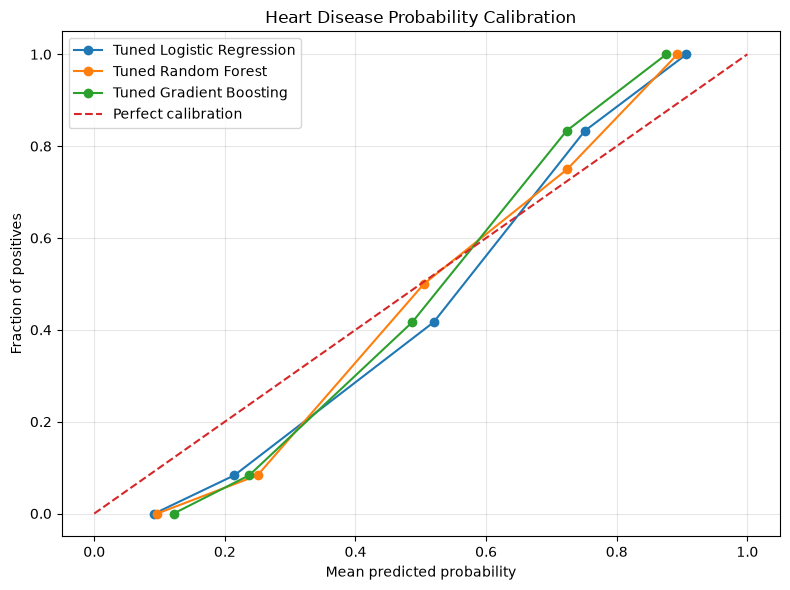

In [38]:
# ============================================================
# PROBABILITY CALIBRATION CHECK
# ============================================================

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, pipeline in tuned_pipelines.items():

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fraction_positive, mean_predicted = calibration_curve(
        y_test,
        y_prob,
        n_bins=5,
        strategy="quantile"
    )

    plt.plot(
        mean_predicted,
        fraction_positive,
        marker="o",
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Heart Disease Probability Calibration")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import brier_score_loss

print("BRIER SCORES")
print("=" * 50)

for name, pipeline in tuned_pipelines.items():

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    score = brier_score_loss(y_test, y_prob)

    print(f"{name}: {score:.4f}")

BRIER SCORES
Tuned Logistic Regression: 0.0864
Tuned Random Forest: 0.1034
Tuned Gradient Boosting: 0.1012


In [40]:
# ============================================================
# FINAL HEART DISEASE MODEL
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

final_heart_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                C=0.1,
                penalty="l2",
                solver="liblinear",
                random_state=42
            )
        )
    ]
)

final_heart_pipeline.fit(X_train, y_train)

print("Final Heart Disease model trained successfully.")
print(type(final_heart_pipeline))

Final Heart Disease model trained successfully.
<class 'sklearn.pipeline.Pipeline'>


c:\Users\mvans\OneDrive\Desktop\Healytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [41]:
# Final model evaluation

final_predictions = final_heart_pipeline.predict(X_test)
final_probabilities = final_heart_pipeline.predict_proba(X_test)[:, 1]

print("Final model test accuracy:",
      round(accuracy_score(y_test, final_predictions), 4))

print("Final model test ROC-AUC:",
      round(roc_auc_score(y_test, final_probabilities), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_predictions,
    target_names=["No Heart Disease", "Heart Disease"]
))

Final model test accuracy: 0.8852
Final model test ROC-AUC: 0.9665

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.85      0.89        33
   Heart Disease       0.84      0.93      0.88        28

        accuracy                           0.89        61
       macro avg       0.89      0.89      0.89        61
    weighted avg       0.89      0.89      0.89        61



In [42]:
# ============================================================
# SAVE FINAL HEART DISEASE PIPELINE
# ============================================================

import os
import joblib

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

heart_model_path = os.path.join(
    models_dir,
    "heart_disease_pipeline.joblib"
)

joblib.dump(final_heart_pipeline, heart_model_path)

print("Heart Disease pipeline saved successfully.")
print("Path:", heart_model_path)
print("File exists:", os.path.exists(heart_model_path))
print(
    "File size:",
    round(os.path.getsize(heart_model_path) / 1024, 2),
    "KB"
)

Heart Disease pipeline saved successfully.
Path: ../models\heart_disease_pipeline.joblib
File exists: True
File size: 5.97 KB


In [43]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

loaded_heart_pipeline = joblib.load(heart_model_path)

print("Saved Heart Disease pipeline loaded successfully.")
print(type(loaded_heart_pipeline))

Saved Heart Disease pipeline loaded successfully.
<class 'sklearn.pipeline.Pipeline'>
